In [ ]:
# Upload Kaggle API key (Make sure kaggle.json is uploaded in Colab environment)
from google.colab import files
files.upload()

# Create the Kaggle directory and move API key there
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset from Kaggle
!kaggle datasets download -d uraninjo/augmented-alzheimer-mri-dataset
!unzip -q augmented-alzheimer-mri-dataset.zip -d /content/data


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset
License(s): GNU Lesser General Public License 3.0
 99% 376M/380M [00:12<00:00, 29.0MB/s]
100% 380M/380M [00:12<00:00, 31.6MB/s]


In [ ]:

import os
import pandas as pd

# Define new dataset directories in Colab
MildDemented_dir = r'/content/data/AugmentedAlzheimerDataset/MildDemented'
ModerateDemented_dir = r'/content/data/AugmentedAlzheimerDataset/ModerateDemented'
NonDemented_dir = r'/content/data/AugmentedAlzheimerDataset/NonDemented'
VeryMildDemented_dir = r'/content/data/AugmentedAlzheimerDataset/VeryMildDemented'

filepaths = []
labels = []
dict_list = [MildDemented_dir, ModerateDemented_dir, NonDemented_dir, VeryMildDemented_dir]
class_labels = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

for i, j in enumerate(dict_list):
    flist = os.listdir(j)
    for f in flist:
        fpath = os.path.join(j, f)
        filepaths.append(fpath)
        labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
Alzheimer_data = pd.concat([Fseries, Lseries], axis=1)
Alzheimer_df = pd.DataFrame(Alzheimer_data)
print(Alzheimer_df.head())
print(Alzheimer_df["labels"].value_counts())


                                           filepaths         labels
0  /content/data/AugmentedAlzheimerDataset/MildDe...  Mild Demented
1  /content/data/AugmentedAlzheimerDataset/MildDe...  Mild Demented
2  /content/data/AugmentedAlzheimerDataset/MildDe...  Mild Demented
3  /content/data/AugmentedAlzheimerDataset/MildDe...  Mild Demented
4  /content/data/AugmentedAlzheimerDataset/MildDe...  Mild Demented
labels
Non Demented         9600
Mild Demented        8960
Very MildDemented    8960
Moderate Demented    6464
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import keras
import warnings
warnings.filterwarnings(action="ignore")
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import TensorBoard,EarlyStopping

import sklearn.metrics as metrics
from keras.callbacks import LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator

annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x, verbose=0)

In [ ]:
Alzheimer_df.shape

(33984, 2)

In [ ]:
train_images, test_images = train_test_split(Alzheimer_df, test_size=0.3, random_state=42)
train_set, val_set = train_test_split(Alzheimer_df, test_size=0.2, random_state=42)

In [ ]:
print(train_set.shape)
print(test_images.shape)
print(val_set.shape)
print(train_images.shape)

(27187, 2)
(10196, 2)
(6797, 2)
(23788, 2)


In [ ]:
image_gen = ImageDataGenerator(preprocessing_function= tf.keras.applications.mobilenet_v2.preprocess_input)
train = image_gen.flow_from_dataframe(dataframe= train_set,x_col="filepaths",y_col="labels",
                                      target_size=(244,244),
                                      color_mode='rgb',
                                      class_mode="categorical", #used for Sequential Model
                                      batch_size=32,
                                      shuffle=False            #do not shuffle data
                                     )
test = image_gen.flow_from_dataframe(dataframe= test_images,x_col="filepaths", y_col="labels",
                                     target_size=(244,244),
                                     color_mode='rgb',
                                     class_mode="categorical",
                                     batch_size=32,
                                     shuffle= False
                                    )
val = image_gen.flow_from_dataframe(dataframe= val_set,x_col="filepaths", y_col="labels",
                                    target_size=(244,244),
                                    color_mode= 'rgb',
                                    class_mode="categorical",
                                    batch_size=32,
                                    shuffle=False
                                   )

Found 27187 validated image filenames belonging to 4 classes.
Found 10196 validated image filenames belonging to 4 classes.
Found 6797 validated image filenames belonging to 4 classes.


In [ ]:
classes=list(train.class_indices.keys())
print (classes)

['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']


In [ ]:
def show_zheimer_images(image_gen):
    test_dict = test.class_indices
    classes = list(test_dict.keys())
    images, labels=next(image_gen) # get a sample batch from the generator
    plt.figure(figsize=(20,20))
    length = len(labels)
    if length<25:
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5,5,i+1)
        image=(images[i]+1)/2 #scale images between 0 and 1
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color="green",fontsize=16)
        plt.axis('off')
    plt.show()

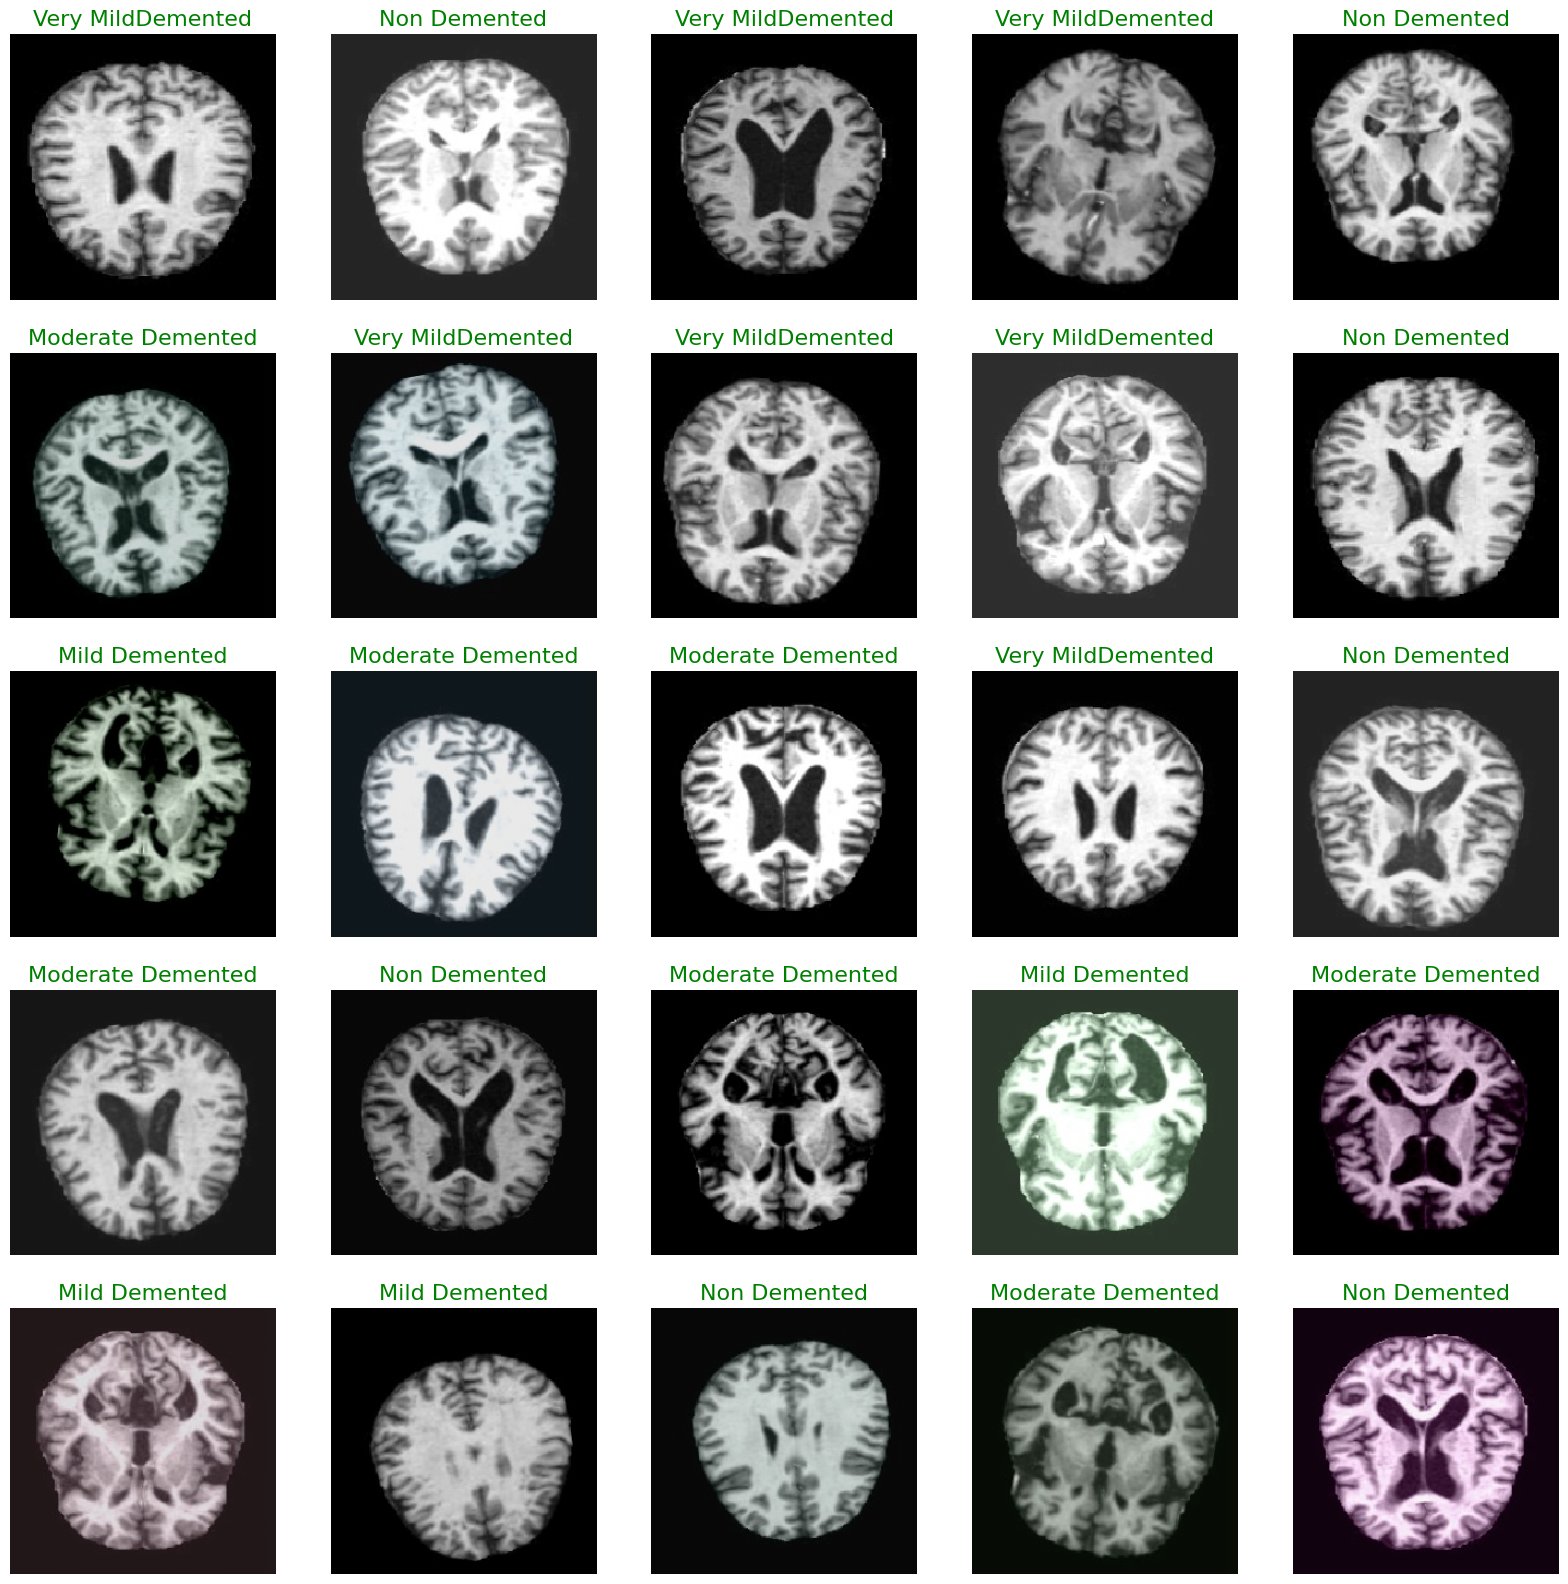

In [ ]:
show_zheimer_images(train)

In [ ]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(244, 244, 3), pooling=None)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)  # Add your custom dense layers here
predictions = Dense(4, activation='softmax')(x)  # Modify num_classes according to your problem

model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# model.summary()

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
history = model.fit(train, epochs=25, validation_data=val, validation_freq=1)

Epoch 1/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 237s 231ms/step - accuracy: 0.5716 - loss: 1.1385 - val_accuracy: 0.6850 - val_loss: 0.6898
Epoch 2/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 151s 177ms/step - accuracy: 0.7096 - loss: 0.6485 - val_accuracy: 0.7600 - val_loss: 0.5669
Epoch 3/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 151s 177ms/step - accuracy: 0.7477 - loss: 0.5664 - val_accuracy: 0.7581 - val_loss: 0.5868
Epoch 4/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 151s 177ms/step - accuracy: 0.7847 - loss: 0.4945 - val_accuracy: 0.7973 - val_loss: 0.4684
Epoch 5/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 151s 177ms/step - accuracy: 0.8088 - loss: 0.4507 - val_accuracy: 0.8093 - val_loss: 0.4447
Epoch 6/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 151s 177ms/step - accuracy: 0.8270 - loss: 0.3994 - val_accuracy: 0.8346 - val_loss: 0.3856
Epoch 7/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 151s 177ms/step - accuracy: 0.8539 - loss: 0.3454 - val_accuracy: 0.8192 - val_loss: 0.4118
Epoch 8/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 151s 177ms/step - accuracy: 0.8794 -

In [ ]:
model.evaluate(test, verbose=1)

319/319 ━━━━━━━━━━━━━━━━━━━━ 63s 197ms/step - accuracy: 0.9287 - loss: 0.2183


[0.17113657295703888, 0.9425264596939087]

In [ ]:
model.save("alzheimer_model.keras")

In [ ]:
pred = model.predict(test)
pred = np.argmax(pred, axis=1) #pick class with highest  probability

labels = (train.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred2 = [labels[k] for k in pred]

319/319 ━━━━━━━━━━━━━━━━━━━━ 70s 177ms/step


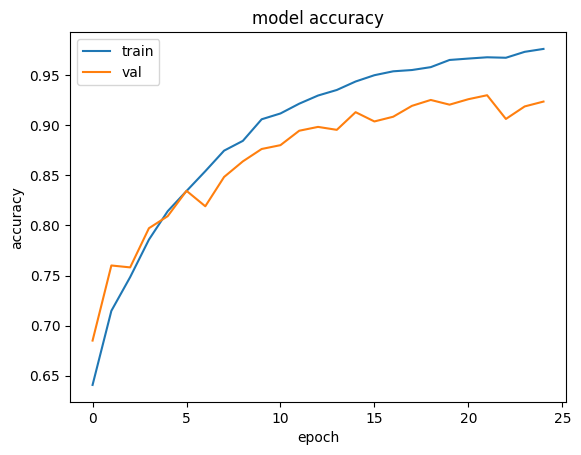

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

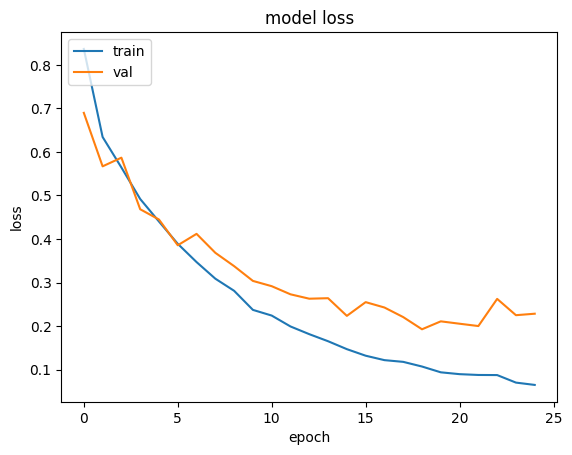

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_test = test_images.labels # set y_test to the expected output
print(classification_report(y_test, pred2))
print("Accuracy of the Model:","{:.1f}%".format(accuracy_score(y_test, pred2)*100))

                   precision    recall  f1-score   support

    Mild Demented       0.94      0.98      0.96      2693
Moderate Demented       1.00      1.00      1.00      1977
     Non Demented       0.93      0.91      0.92      2811
Very MildDemented       0.92      0.90      0.91      2715

         accuracy                           0.94     10196
        macro avg       0.95      0.95      0.95     10196
     weighted avg       0.94      0.94      0.94     10196

Accuracy of the Model: 94.3%


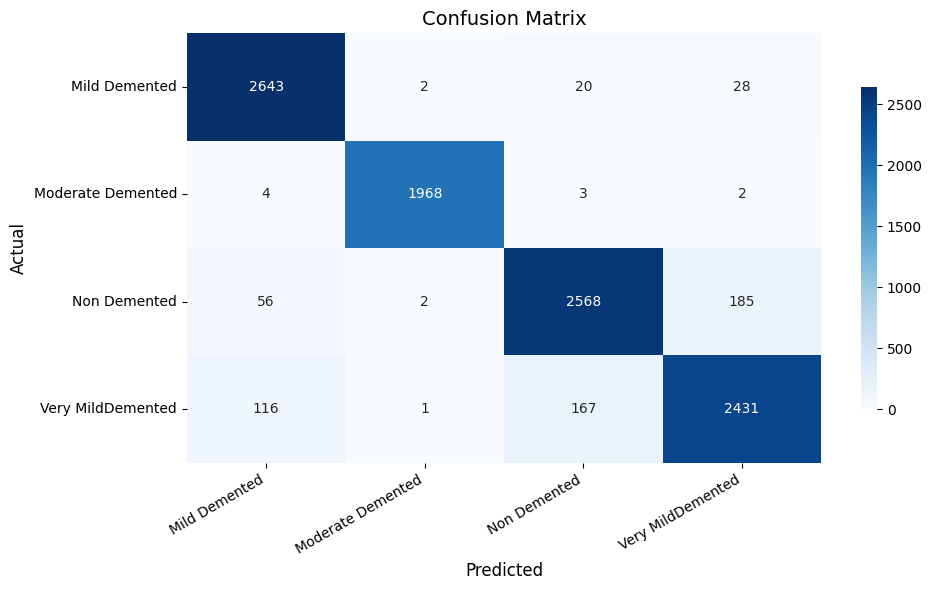

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_labels = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

cm = confusion_matrix(y_test, pred2)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues', cbar_kws={'shrink': 0.75})

# 調整 xticks 和 yticks 的標籤顯示
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels, rotation=30, ha="right", fontsize=10)
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels, rotation=0, va="center", fontsize=10)

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)

plt.tight_layout()  # 自動調整圖形，避免標籤重疊
plt.show()


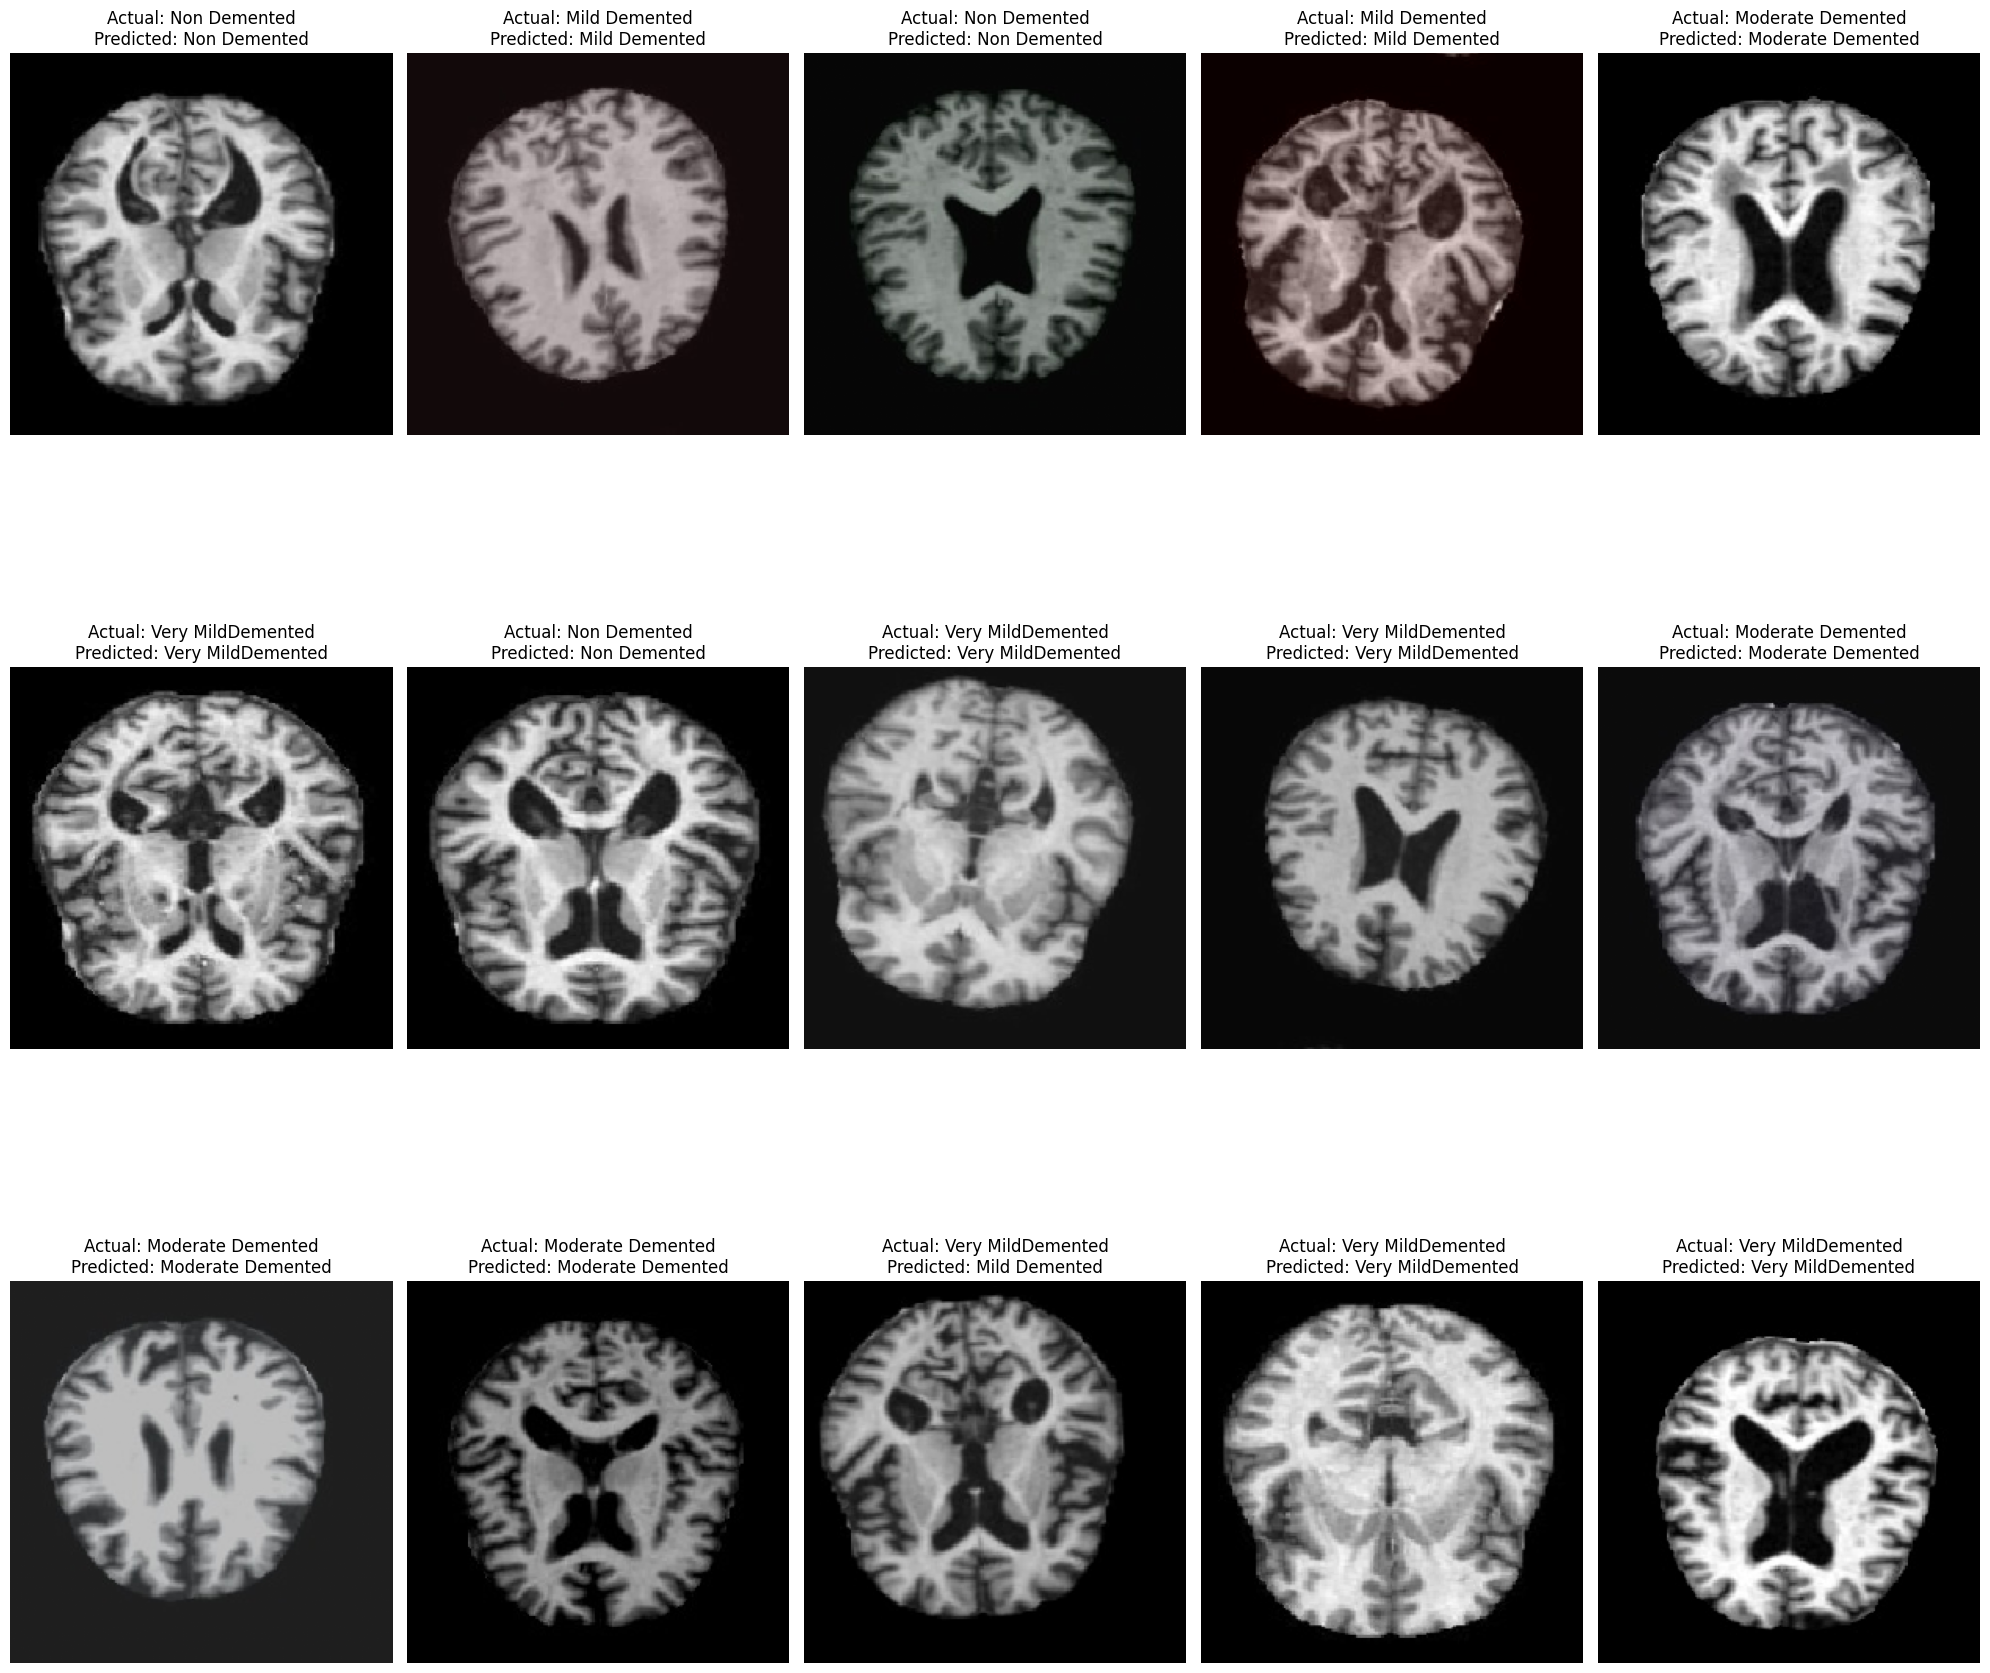

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 從測試數據生成器中獲取一批圖片
images, _ = next(iter(test))  # 提取一個 batch 的圖片

# 確保圖片數據在 [0, 1] 範圍內
images = (images - images.min()) / (images.max() - images.min())

# 獲取測試集的實際標籤
actual_labels = test.classes[:15]  # 前 15 個實際標籤
actual_labels_mapped = [labels[i] for i in actual_labels]

# 獲取測試集的預測標籤
predicted_labels_mapped = pred2[:15]  # 前 15 個預測結果

# 顯示前 15 張測試圖片
plt.figure(figsize=(20, 20))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(images[i])  # 顯示圖片
    plt.title(f"Actual: {actual_labels_mapped[i]}\nPredicted: {predicted_labels_mapped[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
files.download("Zheimer_Model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(model.summary())


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 244, 244, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 250, 250, 3)    │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 122, 122, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 122, 122, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 122, 122, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 124, 124, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 61, 61, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 61, 61, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 61, 61, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 61, 61, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 61, 61, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 61, 61, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 61, 61, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 61, 61, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block2_0_bn    

 Total params: 24,235,598 (92.45 MB)

 Trainable params: 1,971,204 (7.52 MB)

 Non-trainable params: 18,321,984 (69.89 MB)

 Optimizer params: 3,942,410 (15.04 MB)

None
